In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

In [2]:
class SphericalClustering(nn.Module):
    def __init__(self, num_covariates, response_dim, num_clusters, distribution = "pkbd", min_weight=0.05, device='cpu'):
        super(SphericalClustering, self).__init__()
        self.num_covariates = num_covariates
        self.response_dim = response_dim
        self.num_clusters = num_clusters
        self.min_weight = torch.tensor(min_weight)
        self.distribution = distribution
        self.device = device

        # Linear layer to map covariates X to K cluster embeddings (Cx(d*K))
        self.A = nn.Linear(num_covariates, response_dim * num_clusters, bias=False)

        # Preallocate Pi as the log of uniform probabilities (no need for .to(device))
        self.pi = torch.log(torch.ones(1, num_clusters) / num_clusters).to(device)  # Uniform Pi in log space
        # Preallocate W matrix (no need for .to(device))
        self.W = torch.zeros(1, num_clusters)  # Placeholder for the W matrix
        self.loglik = -1e10

        # Placeholder for the mask
        self.mask = torch.ones(1, num_clusters, dtype=torch.bool).to(device)
        self.mask_dynamic = torch.ones(1, num_clusters, dtype=torch.bool).to(device)

    @property
    def active_components(self):
        return torch.sum(self.mask).item()
    
    @property
    def df(self):
        return self.num_covariates * self.response_dim * self.active_components

    def forward(self, X):
        # Forward pass to map covariates X to embeddings
        N = X.size(0)
        embeddings = self.A(X)  # Shape: Nx(d*K)
        embeddings = embeddings.view(N, self.num_clusters, self.response_dim)  # Shape: NxKxd
        embeddings = embeddings[:, self.mask.squeeze()]
        # Compute mu (mean direction) by normalizing across the last dimension
        norms = torch.norm(embeddings, dim=-1, keepdim=True)  # Shape: NxKx1
        mu = embeddings / norms  # Normalized embeddings: NxKxd
        
        # Compute rho by link transformation norm/(norm+1)
        rho = norms / (norms + 1)  # Shape: NxKx1
        
        return mu, rho

    def log_likelihood(self, mu, rho, Y, distribution):
        # Calculate log likelihood for each cluster
        N, K, d = mu.shape
        Y = Y.unsqueeze(2)  # Shape: Nx1xd
        cross_prod = torch.bmm(mu, Y).squeeze(-1)  # NxKx1 -> NxK
        rho = rho.squeeze(-1)  # NxKx1 -> NxK

        term1 = torch.log(1 - rho ** 2)  # NxK
        term2 = torch.log(1 + rho ** 2 - 2 * rho * cross_prod)  # NxK

        if distribution == "pkbd":
            loglik = term1 - d*term2/2 # Shape: NxK
        elif distribution == "spcauchy":
            loglik = (d-1)*term1 - (d-1)*term2  # Shape: NxK
        else:
            raise ValueError("Model must be 'pkbd' or 'spcauchy'")
        
        return loglik

    def E_step(self, loglik_detached):
        # E-step: update Pi and W based on log likelihood
        N, K = loglik_detached.shape
        # Sum log-likelihood with log Pi (since Pi is in log space)
        loglik_with_pi = loglik_detached + self.pi  # Element-wise sum with log Pi vector
        
        # Apply softmax to get W (posterior probabilities) NxK
        self.W = torch.softmax(loglik_with_pi, dim=1)

        # Update Pi by column means of W
        new_pi = torch.mean(self.W, dim=0, keepdim=True)  # Shape: 1xK

        mask2 = (new_pi >= self.min_weight)
        if torch.any(~mask2):
            removed_clusters = (torch.arange(self.num_clusters)+1).unsqueeze(0).to(self.device)[self.mask][~mask2.squeeze()].tolist()
            updated_mask = self.mask.clone()  # Clone the current mask to avoid in-place memory issues
            updated_mask[self.mask] = mask2  # Only update the active part of the original mask
            self.mask = updated_mask
            self.mask_dynamic = mask2
            loglik_with_pi = loglik_with_pi[:, mask2.squeeze()]
            self.W = torch.softmax(loglik_with_pi, dim=1)
            self.pi = torch.log(torch.mean(self.W, dim=0, keepdim=True))  
            print(f"Clusters {removed_clusters} were removed in this iteration.")
            removed = True
        else:
            self.pi = torch.log(new_pi)
            removed = False

        self.loglik = torch.logsumexp(loglik_with_pi, dim = 1).sum()

        return removed

    def M_step(self, X, Y):
        # Perform full M-step with recalculation of model parameters and multiple optimization steps
        mu, rho = self(X)
        loglik = self.log_likelihood(mu, rho, Y, self.distribution)
        # Perform backward pass based on the current W
        W_colnorm = self.W / (torch.sum(self.W, dim=0, keepdim=True))  # Column normalize W
        weighted_loglik = loglik * W_colnorm  # NxK element-wise multiplication
        cluster_loglik = torch.sum(weighted_loglik, dim=0)  # 1xK
        loss = -torch.mean(cluster_loglik)  # Minimize negative log likelihood

        return loss
    
    def fit(self, X, Y, num_epochs=100, num_inner_steps=10, lr = 1e-3, tol = 1e-4, plot = True):
        # Fit the model using EM algorithm
        X = X.to(self.device)
        Y = Y.to(self.device)
        optimizer = optim.AdamW(self.parameters(), lr=lr)

        models_loglik_old = torch.tensor(-1e10)

        Loglikelihoods = []

        self.train()
        for epoch in range(num_epochs):
            # E-step
            optimizer.zero_grad()
            mu, rho = self(X)
            loglik = self.log_likelihood(mu, rho, Y, self.distribution)
            loglik_detached = loglik.detach()  # Detach the log-likelihood before the E-step
            rem = self.E_step(loglik_detached)
            if rem:
                loglik = loglik[:, self.mask_dynamic.squeeze()]
            Loglikelihoods.append(self.loglik)

            if torch.abs(self.loglik - models_loglik_old) < tol*100:
                break
            models_loglik_old = self.loglik

            # M-step
            W_colnorm = self.W / torch.sum(self.W, dim=0, keepdim=True)  # Column normalize W
            weighted_loglik = loglik * W_colnorm  # NxK element-wise multiplication
            cluster_loglik = torch.sum(weighted_loglik, dim=0)  # 1xK
            loss = -torch.mean(cluster_loglik)  # Minimize negative log likelihood
            loss.backward()
            optimizer.step()

            # Perform n-1 more M-steps with re-evaluations
            old_loss = 1e10
            for step in range(num_inner_steps):
                optimizer.zero_grad()  # Reset gradients
                loss = self.M_step(X, Y)
                if abs(loss.item() - old_loss) < tol:
                    print(f'   Inner_step {step + 1}/{num_inner_steps}, Loss: {loss.item()}')
                    break
                loss.backward()
                optimizer.step()  # Update model parameters
                old_loss = loss.item()
            loss = loss.item()

            if (epoch + 1) % 1 == 0:
                print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {loss}, Log-likelihood: {self.loglik}')
        
        if plot:
            # plot the log-likelihoods over the epochs and return them
            if self.device == 'cuda':
                Loglikelihoods = [x.cpu().detach().numpy() for x in Loglikelihoods]
            plt.plot(range(epoch+1)[3:], Loglikelihoods[3:])
            plt.xlabel('Epochs')
            plt.ylabel('Log-likelihood')
            plt.title('Log-likelihood over epochs')
        return Loglikelihoods
    
    def predict(self, X):
        # Predict the cluster assignments
        self.eval()
        with torch.inference_mode():
            X = X.to(self.device)
            return self(X)

    def predict_and_cluster(self, X, Y):
        # Predict the cluster assignments and return the cluster assignments
        self.eval()
        with torch.inference_mode():
            X = X.to(self.device)
            Y = Y.to(self.device)
            mu, rho = self(X)
            loglik = self.log_likelihood(mu, rho, Y, self.distribution)
            loglik_with_pi = loglik + self.pi  # Element-wise sum with log Pi vector
            posterior = torch.softmax(loglik_with_pi, dim=1)
            return posterior, mu, rho
                  
       

In [13]:
#device = 'cuda' if torch.cuda.is_available() else 'cpu'
device = "cpu"
N, C, d, K = 200, 2, 1024, 6  # Example dimensions
X = torch.randn(N, C)  # Covariates NxC
Y = torch.randn(N, d)  # Response Nxd
Y = Y / torch.norm(Y, dim=1, keepdim=True)  # Normalize Y

model = SphericalClustering(num_covariates=C, response_dim=d, num_clusters=K, device=device)
model.to(device)  # Move the entire model to the device

SphericalClustering(
  (A): Linear(in_features=2, out_features=6144, bias=False)
)

Epoch 1/100, Loss: 288.3815612792969, Log-likelihood: -59048.7734375
Epoch 2/100, Loss: 282.39697265625, Log-likelihood: -57960.56640625
Epoch 3/100, Loss: 276.32470703125, Log-likelihood: -56821.234375
Epoch 4/100, Loss: 270.25177001953125, Log-likelihood: -55645.32421875
Epoch 5/100, Loss: 264.2506103515625, Log-likelihood: -54463.35546875
Epoch 6/100, Loss: 258.2431945800781, Log-likelihood: -53284.375
Epoch 7/100, Loss: 252.2017364501953, Log-likelihood: -52103.4375
Epoch 8/100, Loss: 246.1073455810547, Log-likelihood: -50915.34765625
Epoch 9/100, Loss: 239.9452667236328, Log-likelihood: -49716.46875
Epoch 10/100, Loss: 233.7025146484375, Log-likelihood: -48503.74609375
Epoch 11/100, Loss: 227.3721466064453, Log-likelihood: -47273.76953125
Epoch 12/100, Loss: 220.921142578125, Log-likelihood: -46021.25
Epoch 13/100, Loss: 214.3277587890625, Log-likelihood: -44745.03125
Epoch 14/100, Loss: 207.6216583251953, Log-likelihood: -43443.20703125
Epoch 15/100, Loss: 200.83880615234375, Log

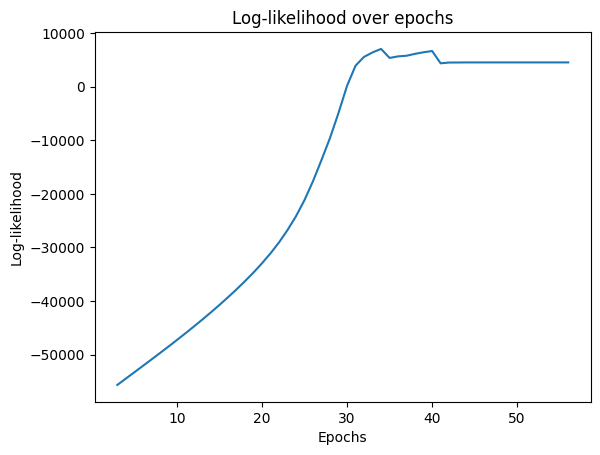

In [14]:
loglikkkks = model.fit(X, Y, num_epochs=100, num_inner_steps=20, lr=1e-3)

In [8]:
model.num_clusters

10

In [ ]:
# Main EM loop
def train_em_model(X, Y, model, num_epochs=100, num_inner_steps=10, lr=1e-3, tol = 1e-3):
    optimizer = optim.AdamW(model.parameters(), lr=lr)
    
    X = X.to(model.device)
    Y = Y.to(model.device)

    models_loglik_old = torch.tensor(-1e10)

    Loglikelihoods = []

    for epoch in range(num_epochs):
        # E-step
        optimizer.zero_grad()
        mu, rho = model(X)
        loglik = model.log_likelihood(mu, rho, Y)
        loglik_detached = loglik.detach()  # Detach the log-likelihood before the E-step
        rem = model.E_step(loglik_detached)
        if rem:
            loglik = loglik[:, model.mask_dynamic.squeeze()]
        Loglikelihoods.append(model.loglik)

        if torch.abs(model.loglik - models_loglik_old) < tol:
            break
        models_loglik_old = model.loglik

        # M-step
        W_colnorm = model.W / torch.sum(model.W, dim=0, keepdim=True)  # Column normalize W
        weighted_loglik = loglik * W_colnorm  # NxK element-wise multiplication
        cluster_loglik = torch.sum(weighted_loglik, dim=0)  # 1xK
        loss = -torch.mean(cluster_loglik)  # Minimize negative log likelihood
        loss.backward()
        optimizer.step()

        # Perform n-1 more M-steps with re-evaluations
        old_loss = 1e10
        for step in range(num_inner_steps):
            optimizer.zero_grad()  # Reset gradients
            loss = model.M_step(X, Y)
            if abs(loss.item() - old_loss) < tol:
                print(f'   Inner_step {step + 1}/{num_inner_steps}, Loss: {loss.item()}')
                break
            loss.backward()
            optimizer.step()  # Update model parameters
            old_loss = loss.item()
        loss = loss.item()

        if (epoch + 1) % 1 == 0:
            print(f'Epoch {epoch + 1}/{num_epochs}, Loss: {loss}, Log-likelihood: {model.loglik}')
    
    # plot the log-likelihoods over the epochs and return them
    plt.plot(range(epoch+1)[3:], Loglikelihoods[3:])
    plt.xlabel('Epochs')
    plt.ylabel('Log-likelihood')
    plt.title('Log-likelihood over epochs')
    return Loglikelihoods